# V2 03 Time Series

This notebook converts the v2 integrated object table into object-level time-series data.

In [1]:
# load project paths and v2 modules.
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import v2_config
from v2_03_time_series import build_v2_time_series

v2_config.ensure_v2_output_dirs()

In [2]:
# define the v2 input and output paths used by this stage.
INTEGRATED_CSV = v2_config.V2_INTEGRATED_OBJECTS_CSV
TIMELINE_CSV = v2_config.V2_OBJECT_TIMELINE_CSV

print(f'integrated input: {INTEGRATED_CSV}')
print(f'timeline output: {TIMELINE_CSV}')

integrated input: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/integration/v2_integrated_objects.csv
timeline output: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/timeline/v2_object_timeline_temperature.csv


In [3]:
# inspect the integrated object table before time-series aggregation.
integrated_df = pd.read_csv(INTEGRATED_CSV)
integrated_role = integrated_df['label'].str.lower().eq(v2_config.PERSON_LABEL).map({True: 'person', False: 'machine'})
print(f'integrated rows: {len(integrated_df):,}')
print(f'columns: {len(integrated_df.columns):,}')
display(integrated_df.head())

display(
    integrated_df.assign(role=integrated_role)
    .groupby(['role', 'label'], dropna=False)
    .size()
    .reset_index(name='rows')
    .sort_values('rows', ascending=False)
)


integrated rows: 219,335
columns: 18


,image_name,timestamp,timestamp_valid,detection_index,label,bbox_x0,bbox_y0,bbox_x1,bbox_y1,temp_mean_c,temp_max_c,pixels,confidence,projected_x,projected_y,object_id,anchor_x,anchor_y
0,IR_57323.jpg,2025-04-23 10:58:00,Y,3,Light,542,9,639,41,32.951767,36.099998,724,0.914885,11.720286,3.714601,light_4,10.635485,3.755376
1,IR_57323.jpg,2025-04-23 10:58:00,Y,2,Machine,239,75,259,97,24.496096,24.884680,107,0.732034,0.805963,0.494620,machine_3,1.256375,0.800275
2,IR_57323.jpg,2025-04-23 10:58:00,Y,1,Person,310,12,417,201,33.995911,35.946697,9397,0.923753,3.583583,1.930686,person_frame_00001,NaN,NaN
3,IR_57323.jpg,2025-04-23 10:58:00,Y,4,Window,292,0,345,64,32.924946,34.327591,1045,0.939321,8.786443,1.498029,window_1,0.656777,0.181031
4,IR_57328.jpg,2025-04-23 14:29:00,Y,18,Light,233,13,280,37,23.174261,24.472921,424,0.934133,2.073165,0.865079,light_1,2.565493,0.939902


,role,label,rows
1,machine,Machine,126359
0,machine,Light,57408
2,machine,Screen,14852
3,machine,Window,11995
4,person,Person,8721


In [4]:
# build one time-series row for each object_id and timestamp.
time_series_settings = SimpleNamespace(
    input_csv=INTEGRATED_CSV,
    output_csv=TIMELINE_CSV,
)

timeline_df = build_v2_time_series(time_series_settings)

print(f'timeline rows: {len(timeline_df):,}')
print(f'timeline objects: {timeline_df["object_id"].nunique():,}')
print(f'wrote: {TIMELINE_CSV}')
display(timeline_df.head())

timeline rows: 71,145
timeline objects: 8,734
wrote: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/timeline/v2_object_timeline_temperature.csv


,timestamp,object_id,label,image_name,detection_index,display_x,display_y,anchor_x,anchor_y,projected_x,...,confidence,pixels,people_count_total,people_count_within_1m,people_count_within_2m,people_count_within_3m,nearest_person_distance,mean_person_distance,nearest_person_dx,nearest_person_dy
0,2025-04-23 10:58:00,light_4,Light,IR_57323.jpg,3,10.635485,3.755376,10.635485,3.755376,11.720286,...,0.914885,724,1,0,0,0,7.284148,7.284148,-7.051902,-1.824690
1,2025-04-23 10:58:00,machine_3,Machine,IR_57323.jpg,2,1.256375,0.800275,1.256375,0.800275,0.805963,...,0.732034,107,1,0,0,1,2.587224,2.587224,2.327208,1.130411
2,2025-04-23 10:58:00,person_frame_00001,Person,IR_57323.jpg,1,3.583583,1.930686,NaN,NaN,3.583583,...,0.923753,9397,0,0,0,0,-1.000000,-1.000000,-1.000000,-1.000000
3,2025-04-23 10:58:00,window_1,Window,IR_57323.jpg,4,0.656777,0.181031,0.656777,0.181031,8.786443,...,0.939321,1045,1,0,0,0,3.409910,3.409910,2.926806,1.749655
4,2025-04-23 14:29:00,light_1,Light,IR_57329.jpg,16,2.565493,0.939902,2.565493,0.939902,2.267850,...,0.938516,446,5,0,0,0,5.038218,8.894858,5.037970,0.050034


In [5]:
# check whether the timeline has one row per object_id and timestamp.
timeline_check = timeline_df.copy()
timeline_check['timestamp_dt'] = pd.to_datetime(timeline_check['timestamp'], errors='coerce')
timeline_role = timeline_check['label'].str.lower().eq(v2_config.PERSON_LABEL).map({True: 'person', False: 'machine'})

duplicate_counts = (
    timeline_check.groupby(['object_id', 'timestamp_dt'])
    .size()
    .reset_index(name='rows')
    .query('rows > 1')
)

print(f'duplicate object/timestamp groups: {len(duplicate_counts):,}')
display(duplicate_counts.head(20))

display(
    timeline_check.assign(role=timeline_role)
    .groupby(['role', 'label'], dropna=False)
    .agg(rows=('object_id', 'size'), objects=('object_id', 'nunique'))
    .reset_index()
    .sort_values('rows', ascending=False)
)


duplicate object/timestamp groups: 0


,object_id,timestamp_dt,rows


,role,label,rows,objects
1,machine,Machine,25461,6
0,machine,Light,23208,4
4,person,Person,8721,8721
2,machine,Screen,7512,2
3,machine,Window,6243,1


,date,role,rows
0,2025-04-23,machine,3192
1,2025-04-23,person,112
2,2025-04-24,machine,4273
3,2025-04-24,person,531
4,2025-04-25,machine,3372
5,2025-04-25,person,270
6,2025-04-29,machine,5206
7,2025-04-29,person,792
8,2025-04-30,machine,4514
9,2025-04-30,person,782


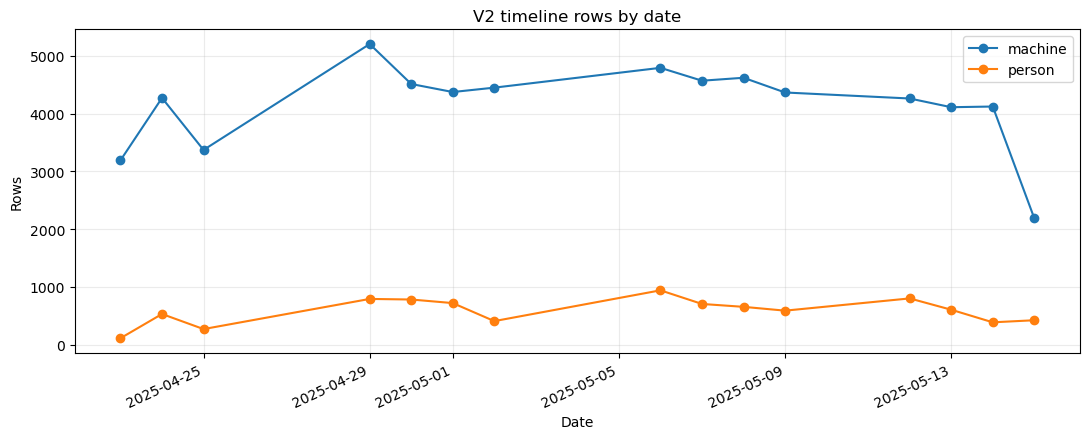

In [6]:
# summarize daily timeline density by object type.
daily_counts = (
    timeline_check.assign(date=timeline_check['timestamp_dt'].dt.date, role=timeline_role)
    .groupby(['date', 'role'], dropna=False)
    .size()
    .reset_index(name='rows')
)
display(daily_counts)

fig, ax = plt.subplots(figsize=(11, 4.5))
for role, role_df in daily_counts.groupby('role'):
    ax.plot(role_df['date'], role_df['rows'], marker='o', label=str(role))
ax.set_title('V2 timeline rows by date')
ax.set_xlabel('Date')
ax.set_ylabel('Rows')
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate(rotation=25)
fig.tight_layout()


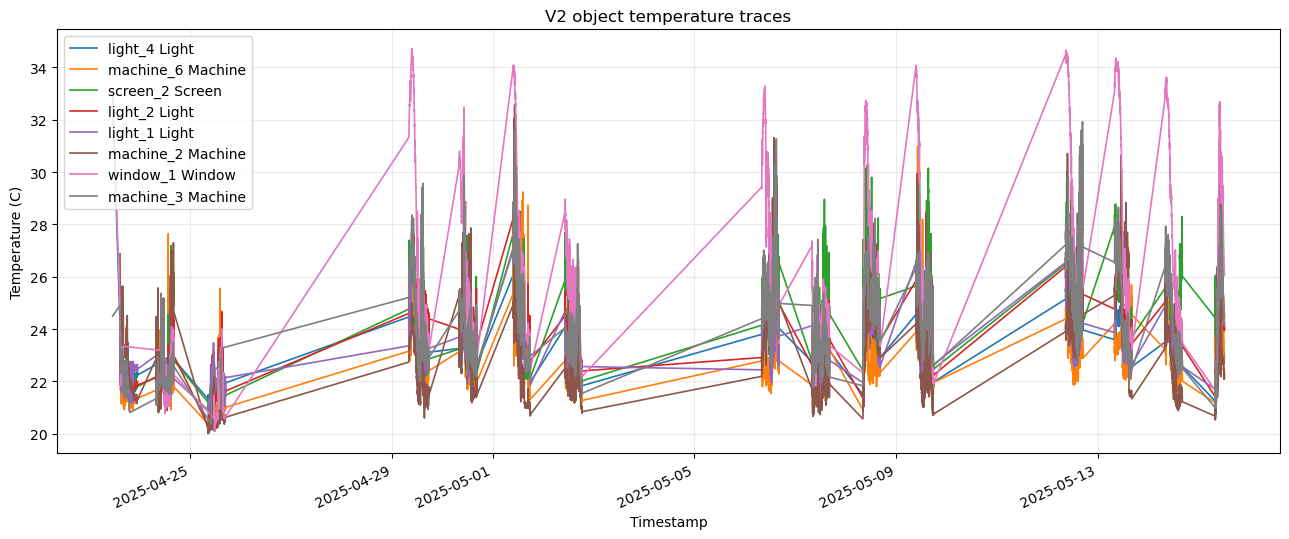

In [7]:
# preview temperature traces for the most frequent static objects.
N_OBJECTS_TO_PLOT = 8
TEMPERATURE_COLUMN = 'temp_mean_c'

machine_timeline = timeline_check[timeline_role == 'machine'].copy()
object_counts = machine_timeline['object_id'].value_counts()
object_ids_to_plot = object_counts.head(N_OBJECTS_TO_PLOT).index.tolist()

fig, ax = plt.subplots(figsize=(13, 5.5))
for object_id in object_ids_to_plot:
    object_df = machine_timeline[machine_timeline['object_id'] == object_id].sort_values('timestamp_dt')
    label = object_df['label'].mode().iloc[0] if not object_df['label'].mode().empty else ''
    ax.plot(object_df['timestamp_dt'], object_df[TEMPERATURE_COLUMN], linewidth=1.2, label=f'{object_id} {label}')

ax.set_title('V2 object temperature traces')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Temperature (C)')
ax.grid(alpha=0.25)
ax.legend(loc='best')
fig.autofmt_xdate(rotation=25)
fig.tight_layout()


In [8]:
# optional GIF rendering from the original 06 workflow is kept here but disabled.
# remove the triple quotes only when daily timeline GIFs are needed.
'''
from IPython.display import Image as DisplayImage, display
from v2_03_animate_timeline import build_daily_animations

RUN_DAILY_ANIMATION = True
DISPLAY_FIRST_GIF = False

animation_settings = SimpleNamespace(
    input_csv=v2_config.V2_OBJECT_TIMELINE_CSV,
    layout=v2_config.LAYOUT_IMAGE,
    output=v2_config.V2_TIMELINE_GIF,
    daily_output_dir=v2_config.V2_DAILY_ANIMATION_OUTPUT_DIR,
    map_width=v2_config.MAP_WIDTH,
    map_height=v2_config.MAP_HEIGHT,
    fps=4,
    temperature_column='temp_mean_c',
    machine_min_observations=2,
    people_min_observations=1,
    max_frames=None,
    day=None,
    split_by_day=True,
)

if RUN_DAILY_ANIMATION:
    gif_paths = build_daily_animations(animation_settings)
    print(f'Generated {len(gif_paths)} daily GIFs')
    for path in gif_paths:
        print(path)
    if DISPLAY_FIRST_GIF and gif_paths:
        display(DisplayImage(filename=str(gif_paths[0])))
else:
    print('Daily animation not rendered.')
'''


"\nfrom IPython.display import Image as DisplayImage, display\nfrom v2_03_animate_timeline import build_daily_animations\n\nRUN_DAILY_ANIMATION = True\nDISPLAY_FIRST_GIF = False\n\nanimation_settings = SimpleNamespace(\n    input_csv=v2_config.V2_OBJECT_TIMELINE_CSV,\n    layout=v2_config.LAYOUT_IMAGE,\n    output=v2_config.V2_TIMELINE_GIF,\n    daily_output_dir=v2_config.V2_DAILY_ANIMATION_OUTPUT_DIR,\n    map_width=v2_config.MAP_WIDTH,\n    map_height=v2_config.MAP_HEIGHT,\n    fps=4,\n    temperature_column='temp_mean_c',\n    machine_min_observations=2,\n    people_min_observations=1,\n    max_frames=None,\n    day=None,\n    split_by_day=True,\n)\n\nif RUN_DAILY_ANIMATION:\n    gif_paths = build_daily_animations(animation_settings)\n    print(f'Generated {len(gif_paths)} daily GIFs')\n    for path in gif_paths:\n        print(path)\n    if DISPLAY_FIRST_GIF and gif_paths:\n        display(DisplayImage(filename=str(gif_paths[0])))\nelse:\n    print('Daily animation not rendered.')\